

## COMM3180 Spring 2026 - _Stories from Data_

### Instructor: Matt O'Donnell (mbod@asc.upenn.edu)

------------


## Shooting victims in Philadelphia

![](img/shootings_heatmap.png)



### Exploring the dataset

* Data is available from opendataphily.org
    * https://www.opendataphilly.org/dataset/shooting-victims
    <br/><br/>


* [Metadata information](http://metadata.phila.gov/#home/datasetdetails/5719551277d6389f3005a610/representationdetails/5719551277d6389f3005a614/)


* CSV version downloaded 03/16/26

    * `data/shootings.csv`
    <br/><br/>

* Related Data 
    * Philadelphia Police Districts
        * https://www.opendataphilly.org/dataset/police-districts
        
        
---

* Related articles
    * https://www.theguardian.com/us-news/2021/sep/27/us-murder-rate-increase-2020
    * https://6abc.com/philadelphia-murder-homicides-gun-violence-shooting/11050068/

### Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

import warnings
warnings.simplefilter('ignore')

### 1. Load the data into a data frame

In [2]:
shoot_df = pd.read_csv('data/shootings.csv') 

### 2. Investigate the size of the data and _eyeball_ some rows
* Key questions
    1. What does each row in the dataset represent?
    2. Which columns central to exploring stories in these data?
    3. What kinds of questions are possible given the data available (e.g. if age/race/ethnicity/other demographic information is available)?

In [3]:
shoot_df.shape

(17516, 25)

In [4]:
shoot_df.columns

Index(['the_geom', 'the_geom_webmercator', 'objectid', 'year', 'dc_key',
       'code', 'date_', 'time', 'race', 'sex', 'age', 'wound',
       'officer_involved', 'offender_injured', 'offender_deceased', 'location',
       'latino', 'point_x', 'point_y', 'dist', 'inside', 'outside', 'fatal',
       'lat', 'lng'],
      dtype='str')

* Some of these columns are not mention in the metadata entry that lists 20 columns

* Looks like there could be duplication (e.g. `point_x` and `lng`, `point_y` and `lat` etc) and extra fields added for a specific dashboard/application use.

In [5]:
shoot_df.head()

,the_geom,the_geom_webmercator,objectid,year,dc_key,code,date_,time,race,sex,...,location,latino,point_x,point_y,dist,inside,outside,fatal,lat,lng
0,0101000020E61000003CDB07ACFEC752C08841D6A92B03...,0101000020110F0000BA1043EEDCE65FC1DE02479C6993...,1,2021,2.021250e+11,100.0,2021-04-18,06:16:00,W,F,...,4800 BLOCK N HOWARD ST,0.0,-75.124919,40.024770,25.0,1.0,0.0,1.0,40.024770,-75.124919
1,0101000020E61000008CD8ADB931CA52C0C8B91833E402...,0101000020110F000053465B5599EA5FC1B9C82C5A1A93...,2,2021,2.021390e+11,100.0,2021-04-07,14:43:00,B,M,...,2000 BLOCK WINDRIM AVE,0.0,-75.159285,40.022589,39.0,0.0,1.0,1.0,40.022589,-75.159285
2,0101000020E61000008CD8ADB931CA52C0C8B91833E402...,0101000020110F000053465B5599EA5FC1B9C82C5A1A93...,3,2021,2.021390e+11,100.0,2021-04-07,14:43:00,B,M,...,2000 BLOCK WINDRIM AVE,0.0,-75.159285,40.022589,39.0,0.0,1.0,0.0,40.022589,-75.159285
3,0101000020E6100000DC861B6728C852C0800655890300...,0101000020110F000063028BD023E75FC13C7C9D7DE98F...,4,2023,2.023250e+11,100.0,2023-02-16,04:55:00,W,M,...,100 BLOCK E WESTMORLAND ST,1.0,-75.127466,40.000108,25.0,0.0,1.0,1.0,40.000108,-75.127466
4,0101000020E6100000DC861B6728C852C0800655890300...,0101000020110F000063028BD023E75FC13C7C9D7DE98F...,5,2023,2.023390e+11,400.0,2023-02-16,04:55:00,W,F,...,100 BLOCK E WESTMORLAND ST,1.0,-75.127466,40.000108,25.0,0.0,1.0,0.0,40.000108,-75.127466


* looks like each row is a shooting incident

* looks like geo location duplicate across four columns
    * `lng` = `point_x`
    * `lat` = `point_y`
    
* question: do more shootings occur inside or outside?
* who do demographic columns refer to:
    * e.g. age, sex, race - offender or victim?

* What are `the_geom` and `the_geom_webmercator` columns?


* Do we need them?

In [6]:
shoot_df['the_geom_webmercator']

0        0101000020110F0000BA1043EEDCE65FC1DE02479C6993...
1        0101000020110F000053465B5599EA5FC1B9C82C5A1A93...
2        0101000020110F000053465B5599EA5FC1B9C82C5A1A93...
3        0101000020110F000063028BD023E75FC13C7C9D7DE98F...
4        0101000020110F000063028BD023E75FC13C7C9D7DE98F...
                               ...                        
17511    0101000020110F0000FA682ADFB2F35FC18B57816DD68B...
17512    0101000020110F0000D4398B5B7AE95FC16F2E15EB1D8E...
17513    0101000020110F00004CC0A1F932EA5FC14D9A3D8FD997...
17514    0101000020110F0000DD76C41E9BEA5FC1E919F9484184...
17515    0101000020110F0000DC76D4790EEB5FC129181FF4CC87...
Name: the_geom_webmercator, Length: 17516, dtype: str

In [7]:
shoot_df['the_geom'].head(10)

0    0101000020E61000003CDB07ACFEC752C08841D6A92B03...
1    0101000020E61000008CD8ADB931CA52C0C8B91833E402...
2    0101000020E61000008CD8ADB931CA52C0C8B91833E402...
3    0101000020E6100000DC861B6728C852C0800655890300...
4    0101000020E6100000DC861B6728C852C0800655890300...
5    0101000020E6100000189FB71BFEC452C05038C7950705...
6    0101000020E6100000189FB71BFEC452C05038C7950705...
7    0101000020E6100000189FB71BFEC452C05038C7950705...
8    0101000020E6100000A47AF59B50CD52C0582B874199FC...
9    0101000020E6100000B40380F31ACA52C088BC94106502...
Name: the_geom, dtype: str

* Looks like some encoded information for a specific application (probably related to geodata)


* We will ignore for now

### 3. Look at columns and kinds and range of data captured in dataset

In [8]:
shoot_df.columns

Index(['the_geom', 'the_geom_webmercator', 'objectid', 'year', 'dc_key',
       'code', 'date_', 'time', 'race', 'sex', 'age', 'wound',
       'officer_involved', 'offender_injured', 'offender_deceased', 'location',
       'latino', 'point_x', 'point_y', 'dist', 'inside', 'outside', 'fatal',
       'lat', 'lng'],
      dtype='str')

* what is `dist`? - distance? from what? - probably district
    * checking the metadata confirms that it is __POLICE DISTRICT__

In [9]:
# how many values in the dist column?
shoot_df['dist'].nunique()

22

In [10]:
# what are the distinct values?
shoot_df['dist'].unique()

array([25., 39.,  2., 16., 22., 15., 24., 19., 18., 26., 35., 14., 12.,
        6.,  9., 17.,  1.,  3.,  5.,  7.,  8., nan, 77.])

In [11]:
# how are they distributed?
shoot_df['dist'].value_counts()

dist
25.0    2111
22.0    1991
24.0    1716
35.0    1381
39.0    1314
15.0    1284
12.0    1269
19.0    1225
14.0     919
18.0     841
16.0     823
26.0     579
17.0     464
2.0      458
3.0      338
1.0      253
6.0      189
9.0      149
8.0      118
7.0       49
5.0       40
77.0       3
Name: count, dtype: int64

* We will come back and look at the file `data/Boundaries_District.csv` in more detail. But if we load it and take a quick look:

In [12]:
districts_df = pd.read_csv('data/Boundaries_District.csv')

In [13]:
districts_df.shape

(22, 14)

In [14]:
districts_df.head()

,OBJECTID,AREA,PERIMETER,DISTRICT_,DISTRICT_ID,DIST_NUM,SUM_AREA,DIST_NUMC,LOCATION,PHONE,DIV_CODE,AREA_SQMI,Shape__Area,Shape__Length
0,343,NaN,69282.588463,16,NaN,16,NaN,16,39th St. & Lancaster Ave.,686-3160,SWPD,1.216700e+08,1.927226e+07,27575.079183
1,344,NaN,33150.154961,17,NaN,17,NaN,17,20th St. & Federal St.,686-3170,SPD,5.786368e+07,9.154950e+06,13179.953350
2,345,NaN,54403.930038,18,NaN,18,NaN,18,55th St. & Pine St.,686-3180,SWPD,9.881929e+07,1.564117e+07,21629.610687
3,346,NaN,51597.051603,35,NaN,35,NaN,35,N. Broad St. & Champlost St.,686-3350,NWPD,1.544309e+08,2.450685e+07,20554.869138
4,347,NaN,58075.014444,39,NaN,39,NaN,39,22nd St. & Hunting Park Ave.,686-3390,NWPD,1.578976e+08,2.503787e+07,23123.580262


In [15]:
districts_df['DIST_NUM'].nunique()

22

In [16]:
districts_df['DIST_NUM'].unique()

array([16, 17, 18, 35, 39,  1,  2,  3, 19, 22, 24, 25, 26, 15, 77,  5,  6,
        7,  8,  9, 12, 14])

* Seems like the `dist` values in the `shoot_df` and those in the `districts_df` align (although one more?)

#### Returning to columns in `shoot_df`

* The `race` column

In [17]:
shoot_df['race'].value_counts()

race
B    14198
W     3011
A      121
U       11
O        1
Name: count, dtype: int64

* Values:
    * B = black
    * W = white
    * A = Asian(?)
    * U=?unknown/unidentified
    * I = indigenous?


* Checking the entry from the metadata field table


| Field Name | Alias | Description | Type |
| --- | --- | --- | --- |
| RACE | Race| The race of the individual shot (Asian, Black, White, American Indian, Other) |	Text |


* __NOTE: We should map these single letter abbreviations to readable labels__


* Probably doesn't help us understand the distribution beyond what we see from using `.value_counts()` but we could do some quick visualization

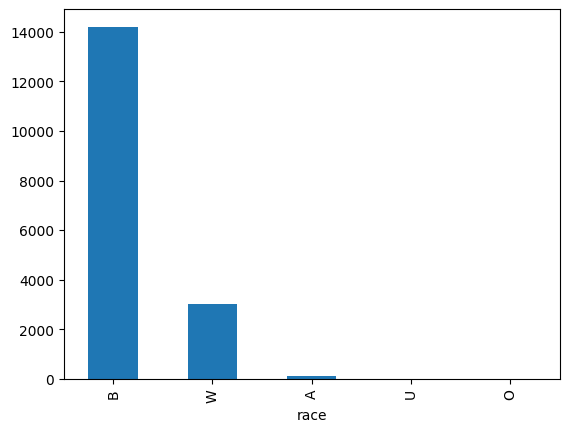

In [18]:
shoot_df['race'].value_counts().plot(kind='bar')
plt.show()

#### WARNING DON'T DO THIS!!!!

* For illustration purposes of how horrible a pie chart is for understanding data take a look at this

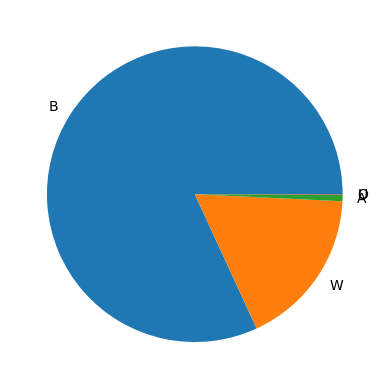

In [19]:
shoot_df['race'].value_counts().plot(kind='pie')
plt.show()

* `pandas` will let you create a pie-chart... but it is strongly discouraged as most data visualization sources will tell you how poorly they communicate proportions. Best to use a bar chart. Enough said!


* The `year` column

In [20]:
shoot_df['year'].value_counts()

year
2021    2342
2022    2269
2020    2259
2023    1672
2019    1473
2018    1447
2016    1342
2015    1294
2017    1265
2024    1112
2025     954
2026      87
Name: count, dtype: int64


* The `date_` column

 
* Looking at a random sample of 20 rows:

In [21]:
shoot_df['date_'].sample(20)

16036    2019-08-29
2788     2017-01-14
17179    2016-01-03
9242     2021-04-14
1321     2021-11-17
2457     2023-06-21
13620    2023-03-25
7938     2016-08-25
2737     2016-10-27
1522     2020-03-11
3955     2023-06-26
11606    2021-01-09
6620     2020-08-01
2088     2023-12-29
719      2021-03-12
8871     2025-09-27
16879    2021-11-16
8126     2017-08-30
16059    2016-08-07
17243    2021-09-04
Name: date_, dtype: str

* `date_` has a `YYYY-MM-DD` format


* The `age` column


* Looks numeric for years old, so can use `.describe() to look at min, max, mean etc.

In [22]:
shoot_df['age'].describe()

count    17215.000000
mean        29.413767
std         11.385377
min          0.000000
25%         21.000000
50%         27.000000
75%         35.000000
max        117.000000
Name: age, dtype: float64

* We could also use `.value_counts()` as it is a fixed set (0-117 years old)

In [23]:
shoot_df['age'].value_counts()

age
21.0     824
20.0     808
23.0     780
22.0     773
19.0     758
        ... 
88.0       1
81.0       1
84.0       1
117.0      1
87.0       1
Name: count, Length: 89, dtype: int64

* And perhaps use a plot of this distribution

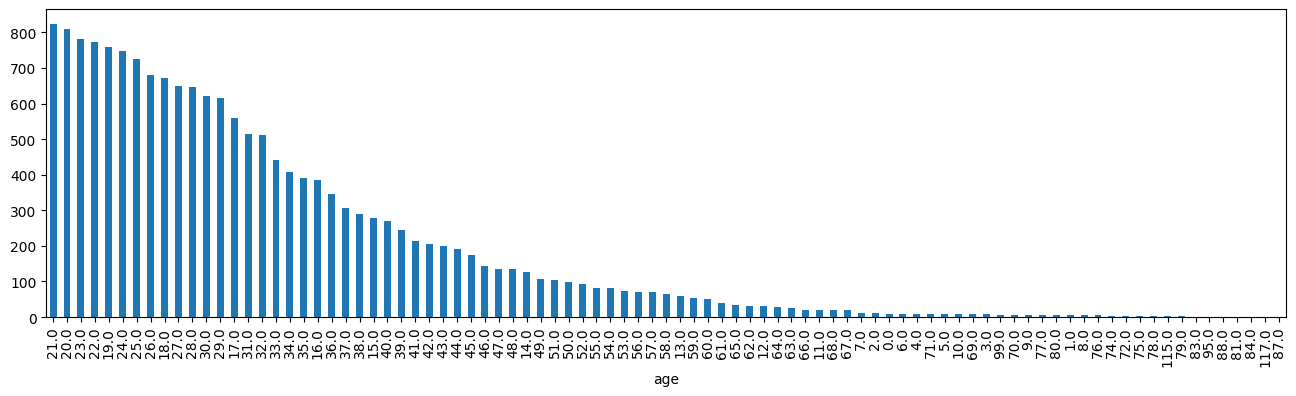

In [24]:
shoot_df['age'].value_counts().plot(kind='bar', figsize=(16,4))
plt.show()

* 20-25 year olds most frequent 


* But this is not that helpful to observe patterns. 


* Below we will use a histogram instead

### 4. Identify the dimensions that could be used for grouping and summarizing

* Look at the types of values in the columns:
    * categorical - groups, kinds, outcomes, etc.
        * `sex`
        * `race` - ?latino col is separate
        * type of shooting
            * `fatal`
            * `location` - inside or not
        * officer involved
        * wound type
    * date
        * `year`
        * `date_` y-m-d
    * location
        * geolocation columns (`point_x`, `lng` etc)
        * `dist` - polic district
    * continuous counts, measurements
        * `age` - but need to add grouping

### 5. Summarize key columns

* Use Pandas functions like `.value_counts()` and `.describe()` and `.count()` to look at the distribution of values


* For continuous values you can use `.plot()` and `.hist()`


* Also try `.plot(kind=bar)` on the result of counting values.

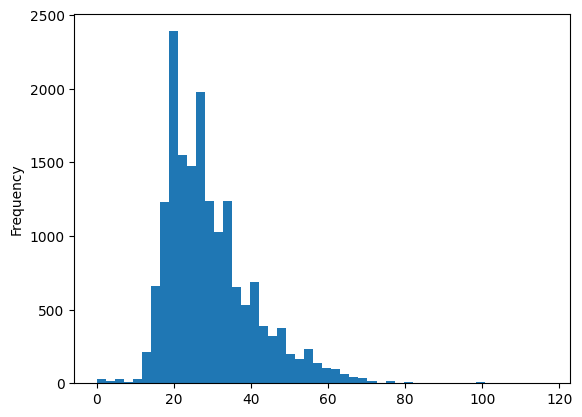

In [25]:
shoot_df['age'].plot(kind='hist', bins=50)
plt.show()

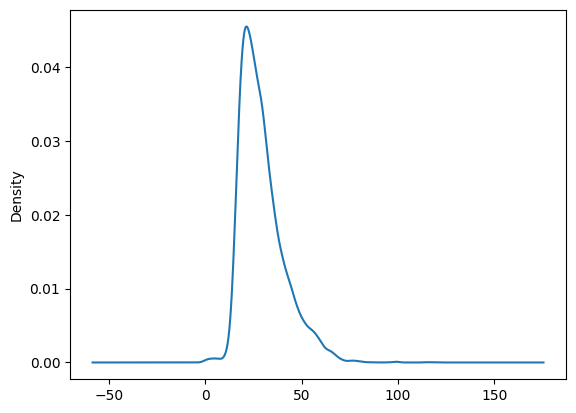

In [26]:
shoot_df['age'].plot(kind='density')
plt.show()

In [27]:
shoot_df['age'].mean()

np.float64(29.41376706360732)

In [28]:
shoot_df['age'].median()

np.float64(27.0)

In [29]:
shoot_df['age'].describe()

count    17215.000000
mean        29.413767
std         11.385377
min          0.000000
25%         21.000000
50%         27.000000
75%         35.000000
max        117.000000
Name: age, dtype: float64

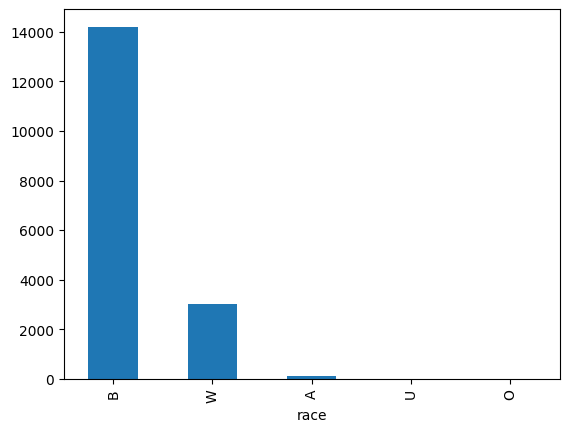

In [30]:
shoot_df['race'].value_counts().plot(kind='bar')
plt.show()

In [31]:
shoot_df['inside'].value_counts()

inside
0.0    16219
1.0     1123
Name: count, dtype: int64

In [32]:
shoot_df['outside'].value_counts()

outside
1.0    16219
0.0     1123
Name: count, dtype: int64

In [33]:
race_mapping = {
    'B': 'BLACK',
    'W': 'WHITE',
    'A': 'ASIAN',
    'I': 'INDIGENOUS',
    'U': 'UNIDENTIFIED/OTHER'
}

### Remapping values with `.map()` function

In [34]:
shoot_df['race'].map(race_mapping).head(10)

0    WHITE
1    BLACK
2    BLACK
3    WHITE
4    WHITE
5    BLACK
6    BLACK
7    WHITE
8    BLACK
9    BLACK
Name: race, dtype: str

In [35]:
race_mapping['B']

'BLACK'

In [36]:
shoot_df['race'].head(10)

0    W
1    B
2    B
3    W
4    W
5    B
6    B
7    W
8    B
9    B
Name: race, dtype: str

In [37]:
shoot_df['race_long']=shoot_df['race'].map(race_mapping)

In [38]:
shoot_df.shape

(17516, 26)

In [39]:
shoot_df[['race','race_long']]

,race,race_long
0,W,WHITE
1,B,BLACK
2,B,BLACK
3,W,WHITE
4,W,WHITE
...,...,...
17511,NaN,NaN
17512,NaN,NaN
17513,NaN,NaN
17514,NaN,NaN


In [40]:
shoot_df['latino'].value_counts()

latino
0.0    15203
1.0     2139
Name: count, dtype: int64

In [41]:
latino_mapping = {
    0 : 'NON-LATINO',
    1 : 'LATINO'
}

In [42]:
shoot_df['latino_long']=shoot_df['latino'].map(latino_mapping)

In [43]:
shoot_df.shape

(17516, 27)

In [44]:
shoot_df['ethnicity']=shoot_df['race_long'] + ' ' + shoot_df['latino_long']

In [45]:
shoot_df['ethnicity'].head(20)

0     WHITE NON-LATINO
1     BLACK NON-LATINO
2     BLACK NON-LATINO
3         WHITE LATINO
4         WHITE LATINO
5     BLACK NON-LATINO
6     BLACK NON-LATINO
7         WHITE LATINO
8     BLACK NON-LATINO
9     BLACK NON-LATINO
10    BLACK NON-LATINO
11    BLACK NON-LATINO
12    BLACK NON-LATINO
13    BLACK NON-LATINO
14        WHITE LATINO
15    BLACK NON-LATINO
16        WHITE LATINO
17    WHITE NON-LATINO
18    BLACK NON-LATINO
19    WHITE NON-LATINO
Name: ethnicity, dtype: str

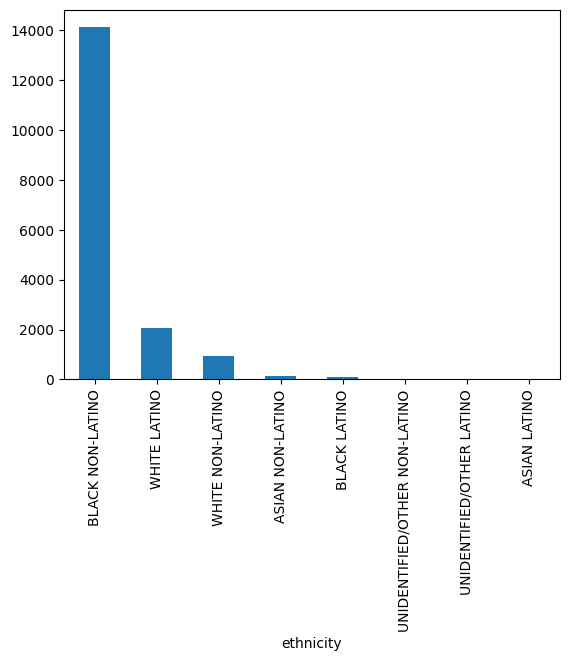

In [46]:
shoot_df['ethnicity'].value_counts().plot(kind='bar')
plt.show()

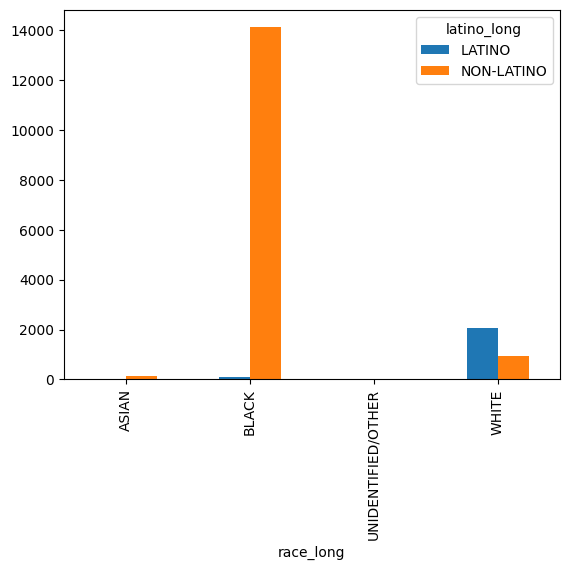

In [47]:
shoot_df.groupby(['race_long', 'latino_long']).size().unstack().plot(kind='bar', stacked=False)
plt.show()

In [48]:
shoot_df.groupby(['race_long', 'latino_long']).size()

race_long           latino_long
ASIAN               LATINO             1
                    NON-LATINO       120
BLACK               LATINO            80
                    NON-LATINO     14118
UNIDENTIFIED/OTHER  LATINO             3
                    NON-LATINO         8
WHITE               LATINO          2055
                    NON-LATINO       956
dtype: int64

In [49]:
shoot_df.count()

the_geom                17516
the_geom_webmercator    17490
objectid                17516
year                    17516
dc_key                  17516
code                    17328
date_                   17516
time                    17342
race                    17342
sex                     17490
age                     17215
wound                   17334
officer_involved        17516
offender_injured        17515
offender_deceased       17516
location                17516
latino                  17342
point_x                 17490
point_y                 17490
dist                    17514
inside                  17342
outside                 17342
fatal                   17342
lat                     17490
lng                     17490
race_long               17341
latino_long             17342
ethnicity               17341
dtype: int64

* not much missing data - come back and check for how missing values are recorded

In [50]:
shoot_df.groupby('sex')['race_long'].value_counts()

sex  race_long         
F    BLACK                  1430
     WHITE                   428
     ASIAN                    22
M    BLACK                 12768
     WHITE                  2583
     ASIAN                    99
     UNIDENTIFIED/OTHER       11
Name: count, dtype: int64

In [51]:
shoot_df[['inside','outside']].corr()

,inside,outside
inside,1.0,-1.0
outside,-1.0,1.0


In [52]:
shoot_df.groupby('year')['fatal'].value_counts(normalize=True)

year  fatal
2015  0.0      0.816680
      1.0      0.183320
2016  0.0      0.801365
      1.0      0.198635
2017  0.0      0.790735
      1.0      0.209265
2018  0.0      0.792334
      1.0      0.207666
2019  0.0      0.786885
      1.0      0.213115
2020  0.0      0.799911
      1.0      0.200089
2021  0.0      0.782441
      1.0      0.217559
2022  0.0      0.789264
      1.0      0.210736
2023  0.0      0.773960
      1.0      0.226040
2024  0.0      0.789474
      1.0      0.210526
2025  0.0      0.779553
      1.0      0.220447
2026  0.0      0.816092
      1.0      0.183908
Name: proportion, dtype: float64

In [53]:
bins=[0,9,19,29,39,49,59,69,79,100]
labels=["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69","70-79", "80+"]

In [54]:
shoot_df['age_group']=pd.cut(shoot_df['age'], bins=bins, labels=labels)

In [55]:
shoot_df[['age', 'age_group']]

,age,age_group
0,29.0,20-29
1,22.0,20-29
2,22.0,20-29
3,34.0,30-39
4,33.0,30-39
...,...,...
17511,NaN,NaN
17512,NaN,NaN
17513,NaN,NaN
17514,NaN,NaN


In [56]:
shoot_df['age_group'].value_counts()

age_group
20-29    7248
30-39    4073
10-19    2895
40-49    1778
50-59     791
60-69     278
0-9        76
70-79      44
80+        19
Name: count, dtype: int64

In [57]:
shoot_df[shoot_df['age_group']=='80+']

,the_geom,the_geom_webmercator,objectid,year,dc_key,code,date_,time,race,sex,...,dist,inside,outside,fatal,lat,lng,race_long,latino_long,ethnicity,age_group
646,0101000020E6100000182702F80ECC52C058BEEDCA6DF7...,0101000020110F0000A2C6BFFAC3ED5FC1DD40D7146686...,642,2023,2.023170e+11,100.0,2023-09-04,09:05:00,W,M,...,17.0,0.0,1.0,1.0,39.933038,-75.188414,WHITE,NON-LATINO,WHITE NON-LATINO,80+
1069,0101000020E6100000B09ED44386C952C080856A226A07...,0101000020110F0000FFE13C1776E95FC16D4B75E41E98...,1058,2019,2.019351e+11,300.0,2019-08-17,00:38:00,B,M,...,35.0,1.0,0.0,0.0,40.057926,-75.148820,BLACK,NON-LATINO,BLACK NON-LATINO,80+
1608,0101000020E6100000A830924A0CCF52C0A8EB0D540CF9...,0101000020110F00004AEBEFF4D7F25FC1C64230433188...,1592,2015,2.015121e+11,400.0,2015-09-26,23:30:00,B,M,...,12.0,0.0,1.0,0.0,39.945689,-75.235125,BLACK,NON-LATINO,BLACK NON-LATINO,80+
1980,0101000020E6100000C453F45F5ECF52C0D01B79831CFB...,0101000020110F00007589486263F35FC19D7EC6747A8A...,1958,2016,2.016180e+11,400.0,2016-04-17,08:50:00,W,M,...,18.0,0.0,1.0,0.0,39.961808,-75.240135,WHITE,NON-LATINO,WHITE NON-LATINO,80+
3629,0101000020E61000000C4C8A69E8C952C0F8E593821F08...,0101000020110F000002B9C8CD1CEA5FC1674DD328E898...,3593,2020,2.020140e+11,100.0,2020-02-10,20:03:00,B,M,...,14.0,1.0,0.0,1.0,40.063462,-75.154810,BLACK,NON-LATINO,BLACK NON-LATINO,80+
5570,0101000020E61000008C5BB8EB66CA52C0E08DED9E84FC...,0101000020110F0000E23AF8B0F3EA5FC14A5D8582098C...,5519,2015,2.015221e+11,100.0,2015-06-23,03:26:00,B,M,...,22.0,0.0,1.0,1.0,39.972797,-75.162532,BLACK,NON-LATINO,BLACK NON-LATINO,80+
7081,0101000020E610000024CCFFD44DCA52C030F07BBF44F7...,0101000020110F000089F25413C9EA5FC109D6ED9E3886...,7019,2020,2.020030e+11,400.0,2020-05-29,06:30:00,W,M,...,3.0,0.0,1.0,0.0,39.931786,-75.161000,WHITE,NON-LATINO,WHITE NON-LATINO,80+
7850,0101000020E6100000288039E557CA52C0E022560AF7FE...,0101000020110F000093564F2BDAEA5FC13BEDC1D4BF8E...,7780,2020,2.020220e+11,400.0,2020-05-18,15:51:00,B,M,...,22.0,0.0,1.0,0.0,39.991914,-75.161615,BLACK,NON-LATINO,BLACK NON-LATINO,80+
9415,0101000020E6100000F06756EE99CE52C030BCB962C0F9...,0101000020110F000038FA4EB415F25FC17A4604BDF888...,9327,2018,2.018180e+11,400.0,2018-07-12,03:15:00,B,M,...,18.0,0.0,1.0,0.0,39.951184,-75.228145,BLACK,NON-LATINO,BLACK NON-LATINO,80+
11014,0101000020E61000006401D39C8ECF52C0E071143766FB...,0101000020110F000090D71452B5F35FC1F32D9F1FCC8A...,10916,2024,2.024190e+11,100.0,2024-03-05,13:36:00,B,M,...,19.0,0.0,1.0,1.0,39.964057,-75.243079,BLACK,NON-LATINO,BLACK NON-LATINO,80+


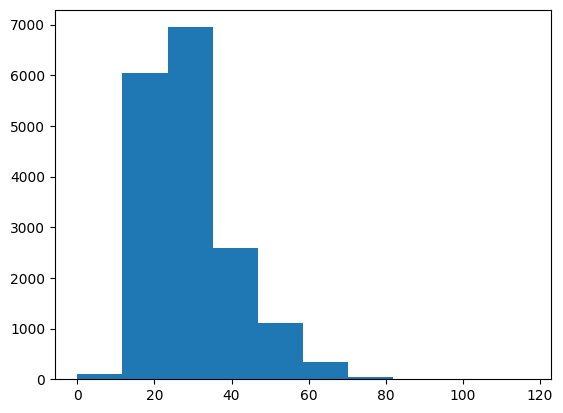

In [58]:
shoot_df['age'].hist(grid=False)
plt.show()

In [59]:
shoot_df['wound'].unique()

<ArrowStringArray>
[         'Head',           'Leg',      'Multiple',          'Foot',
          'Back',      'shoulder',         'Ankle',       'Abdomen',
      'Shoulder',          'head',         'Chest',       'Stomach',
          'Hand', 'Multiple/Head',           'Hip',          'Neck',
           'Arm',      'Buttocks',         'Groin',       'Unknown',
             nan,         'THIGH',         'Wrist',           'leg',
           'arm',           'hip',          'hand',           'LEG',
          'back',          'neck',         'MULTI',          'NECK',
 'MULTIPLE/HEAD',         'chest',          'foot',      'buttocks',
      'SHOULDER',          'BACK',       'STOMACH',          'FOOT',
      'MULTIPLE',         'KNNES',           'ARM',        'Pelvis',
          'HEAD',         'ankle',       'ABDOMEN',         'ANKLE',
         'CHEST',        'pelvis',         'groin',       'stomach',
       'abdomen', 'Multiple/HEAD',          'HAND',          'LEGS',
      'BUTTOCKS

In [60]:
shoot_df[shoot_df['fatal']==1].groupby(['dist','wound']).size()

dist  wound        
1.0   Back              1
      Chest            12
      Head              7
      Multiple         18
      Multiple/Head     4
                       ..
39.0  Neck              3
      Shoulder          2
      Stomach           5
      head              2
77.0  Multiple          1
Length: 244, dtype: int64

In [61]:
shoot_df['code'].value_counts()

code
400.0     11466
100.0      4299
300.0       811
3400.0      318
3000.0      123
3100.0       85
1500.0       76
2700.0       37
3300.0       28
800.0        17
3700.0       12
2600.0       11
500.0         7
600.0         7
1400.0        6
1800.0        5
1300.0        4
2800.0        4
700.0         3
1100.0        2
2000.0        2
1700.0        2
3200.0        2
200.0         1
Name: count, dtype: int64

In [62]:
# Looking at the metadata and UCS codes for classifying crimes

print(
'''
0000: Additional Victim
0100 – 0119: Homicide
0200 – 0299: Rape
0300 – 0399: Robbery
0400 – 0499: Aggravated Assault
3000 – 3900: Hospital Cases
''')

# could create a mapping to go from number to label


0000: Additional Victim
0100 – 0119: Homicide
0200 – 0299: Rape
0300 – 0399: Robbery
0400 – 0499: Aggravated Assault
3000 – 3900: Hospital Cases



In [63]:
def code2type(code):
    
    if code<120:
        incident='Homicide'
    elif code<300:
        incident='Rape'
    elif code<400:
        incident='Robbery'
    elif code<500:
        incident='Aggravated Assault'
    elif code>=3000 and code<4000:
        incident='Hospital Cases'
    else:
        incident=None
    
    return incident

In [64]:
shoot_df['code'].map(code2type)

0                  Homicide
1                  Homicide
2                  Homicide
3                  Homicide
4        Aggravated Assault
                ...        
17511                   NaN
17512                   NaN
17513                   NaN
17514                   NaN
17515                   NaN
Name: code, Length: 17516, dtype: str

In [65]:
shoot_df['code_long'] = shoot_df['code'].map(code2type)

In [66]:
shoot_df['fatal_long']=shoot_df['fatal'].map({0: 'NON-FATAL', 1: 'FATAL'})
shoot_df['outside_long']=shoot_df['outside'].map({0: 'INSIDE', 1: 'OUTSIDE'})

In [67]:
shoot_df['date_YM']=shoot_df['date_'].str[:7]

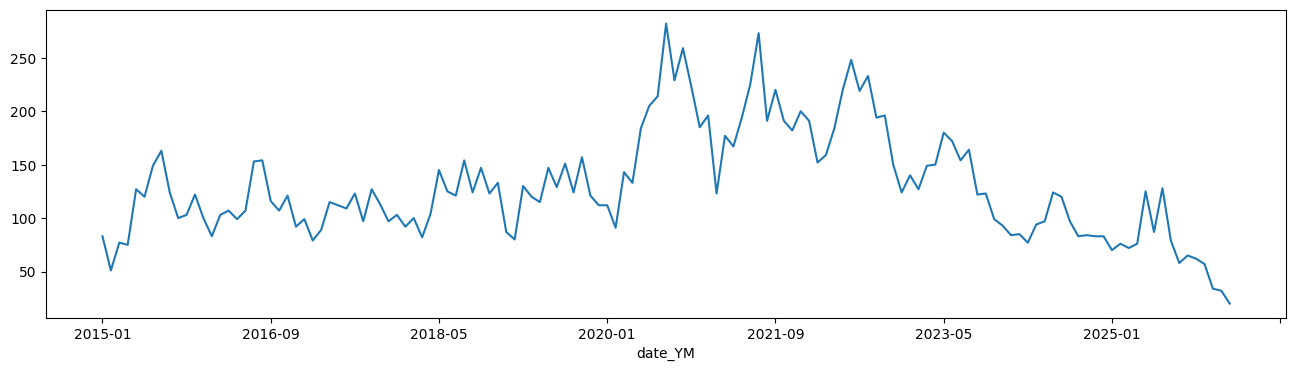

In [68]:
shoot_df.groupby('date_YM').size().plot(figsize=(16,4))
plt.show()

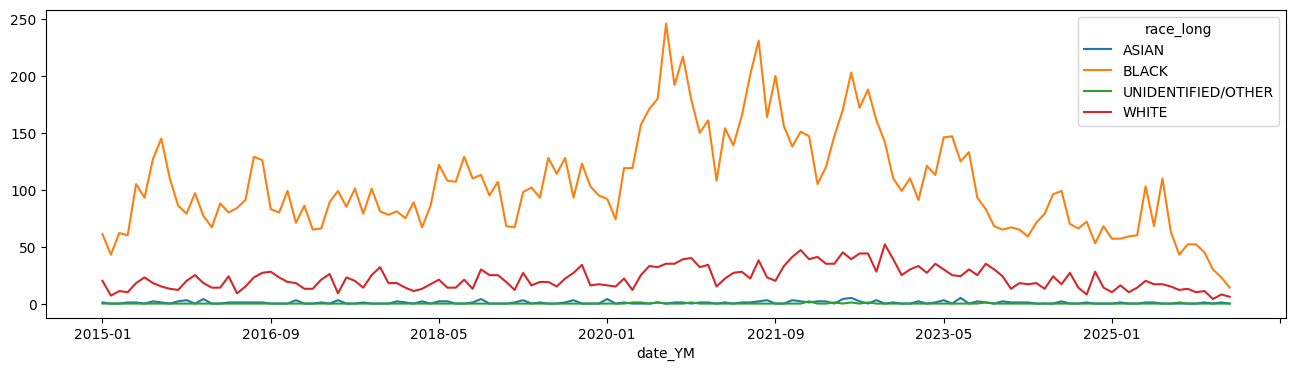

In [69]:
shoot_YM_race = shoot_df.groupby(['date_YM','race_long']).size().unstack().fillna(0)

shoot_YM_race.plot(kind='line',figsize=(16,4), stacked=False)
plt.show()

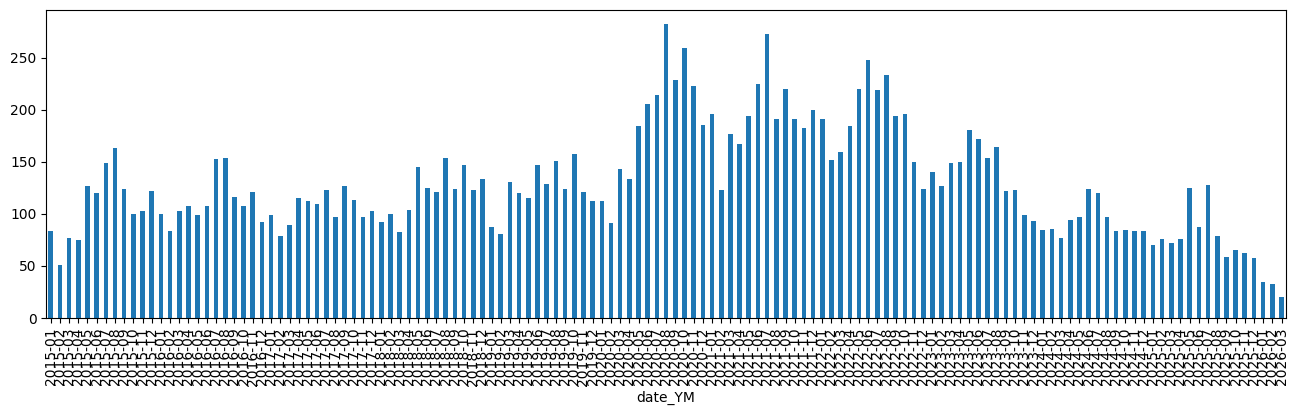

In [70]:
shoot_df.groupby('date_YM').size().plot(figsize=(16,4), kind='bar')
plt.show()

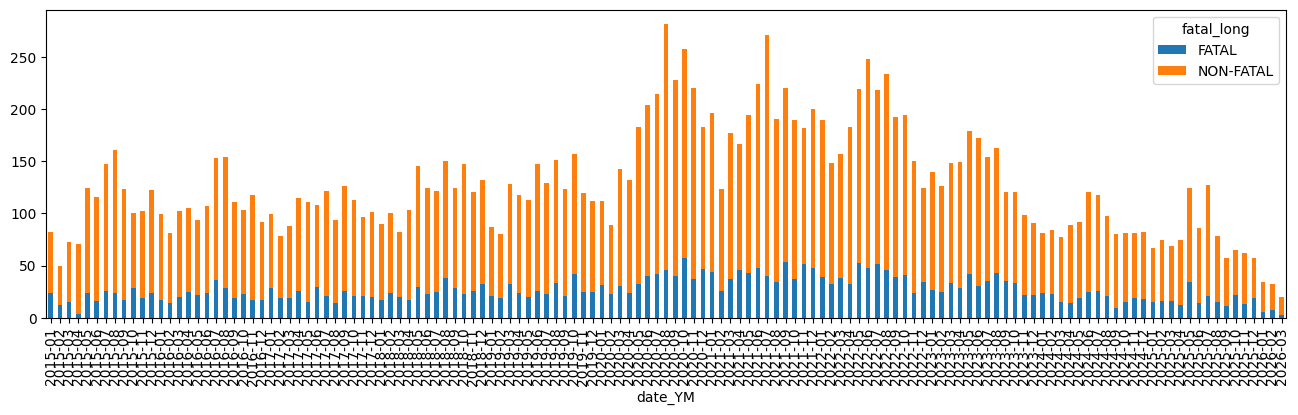

In [71]:
shoot_YM_fatal=shoot_df.groupby(['date_YM','fatal_long']).size().unstack()
shoot_YM_fatal.plot(figsize=(16,4), kind='bar', stacked=True)
plt.show()

### Looking at Polic Districts

In [72]:
shoot_by_dist=shoot_df['dist'].value_counts()

In [73]:
ppd_dist_gdf = gpd.read_file('data/Boundaries_District.geojson')

In [74]:
ppd_dist_gdf.head()

,OBJECTID,AREA,PERIMETER,DISTRICT_,DISTRICT_ID,DIST_NUM,SUM_AREA,DIST_NUMC,LOCATION,PHONE,DIV_CODE,AREA_SQMI,Shape__Area,Shape__Length,geometry
0,343,None,69282.588463,16,None,16,None,16,39th St. & Lancaster Ave.,686-3160,SWPD,1.216700e+08,1.927226e+07,27575.079183,"POLYGON ((-75.19957 40.00912, -75.19799 40.008..."
1,344,None,33150.154961,17,None,17,None,17,20th St. & Federal St.,686-3170,SPD,5.786368e+07,9.154950e+06,13179.953350,"POLYGON ((-75.16599 39.94184, -75.16621 39.940..."
2,345,None,54403.930038,18,None,18,None,18,55th St. & Pine St.,686-3180,SWPD,9.881929e+07,1.564117e+07,21629.610687,"POLYGON ((-75.18466 39.94851, -75.18633 39.947..."
3,346,None,51597.051603,35,None,35,None,35,N. Broad St. & Champlost St.,686-3350,NWPD,1.544309e+08,2.450685e+07,20554.869138,"POLYGON ((-75.13011 40.05789, -75.12898 40.057..."
4,347,None,58075.014444,39,None,39,None,39,22nd St. & Hunting Park Ave.,686-3390,NWPD,1.578976e+08,2.503787e+07,23123.580262,"POLYGON ((-75.17892 40.03175, -75.17782 40.031..."


In [75]:
ppd_dist_gdf['centX']=ppd_dist_gdf.centroid.x
ppd_dist_gdf['centY']=ppd_dist_gdf.centroid.y

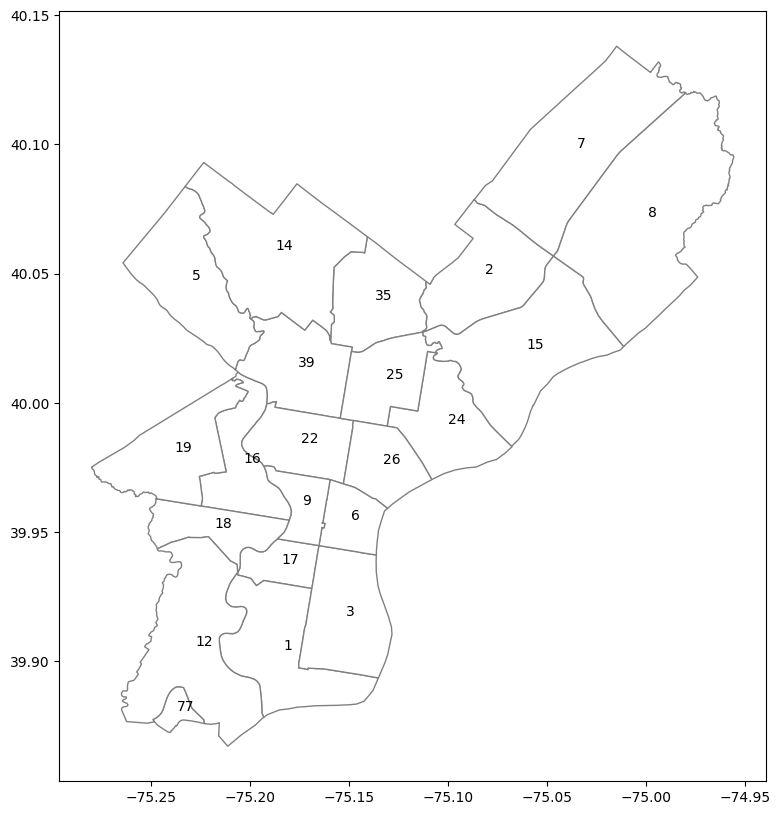

In [76]:
ppd_dist_gdf.plot(color='white', edgecolor='gray', figsize=(10,10))

ppd_dist_gdf.apply(lambda r: plt.text(r['centX'], r['centY'], r['DIST_NUM']),axis=1)
plt.show()

In [77]:
ppd_dist_counts_gdf = ppd_dist_gdf.merge(shoot_by_dist, left_on='DIST_NUM', right_index=True) 

In [78]:
ppd_dist_counts_gdf

,OBJECTID,AREA,PERIMETER,DISTRICT_,DISTRICT_ID,DIST_NUM,SUM_AREA,DIST_NUMC,LOCATION,PHONE,DIV_CODE,AREA_SQMI,Shape__Area,Shape__Length,geometry,centX,centY,count
0,343,None,69282.588463,16,None,16,None,16,39th St. & Lancaster Ave.,686-3160,SWPD,1.216700e+08,1.927226e+07,27575.079183,"POLYGON ((-75.19957 40.00912, -75.19799 40.008...",-75.203673,39.976873,823
1,344,None,33150.154961,17,None,17,None,17,20th St. & Federal St.,686-3170,SPD,5.786368e+07,9.154950e+06,13179.953350,"POLYGON ((-75.16599 39.94184, -75.16621 39.940...",-75.184559,39.937661,464
2,345,None,54403.930038,18,None,18,None,18,55th St. & Pine St.,686-3180,SWPD,9.881929e+07,1.564117e+07,21629.610687,"POLYGON ((-75.18466 39.94851, -75.18633 39.947...",-75.218378,39.951612,841
3,346,None,51597.051603,35,None,35,None,35,N. Broad St. & Champlost St.,686-3350,NWPD,1.544309e+08,2.450685e+07,20554.869138,"POLYGON ((-75.13011 40.05789, -75.12898 40.057...",-75.137001,40.039976,1381
4,347,None,58075.014444,39,None,39,None,39,22nd St. & Hunting Park Ave.,686-3390,NWPD,1.578976e+08,2.503787e+07,23123.580262,"POLYGON ((-75.17892 40.03175, -75.17782 40.031...",-75.175823,40.013999,1314
5,348,None,81903.641825,1,None,1,None,01,24th St. & Wolf St.,686-3010,SPD,2.163501e+08,3.419657e+07,32552.488256,"POLYGON ((-75.19724 39.92944, -75.19693 39.929...",-75.183562,39.904282,253
6,349,None,63587.369399,2,None,2,None,02,7306 Castor Ave,686-3020,NEPD,1.923461e+08,3.053264e+07,25329.930167,"POLYGON ((-75.05444 40.04454, -75.05482 40.044...",-75.081508,40.050009,458
7,350,None,55305.496227,3,None,3,None,03,11th St. & Wharton St.,686-3030,SPD,1.839049e+08,2.907948e+07,22002.676793,"POLYGON ((-75.13205 39.89932, -75.1347 39.8946...",-75.151662,39.917482,338
8,351,None,71654.674103,19,None,19,None,19,61st St. & Thompson St.,686-3190,SWPD,1.782215e+08,2.823350e+07,28509.269384,"POLYGON ((-75.20941 40.00882, -75.20888 40.008...",-75.238351,39.981095,1225
9,352,None,45820.883658,22,None,22,None,22,17th St & Montgomery Ave.,686-3220,CPD,1.201916e+08,1.904228e+07,18230.658403,"POLYGON ((-75.18686 40.00043, -75.18696 40.000...",-75.174447,39.984378,1991


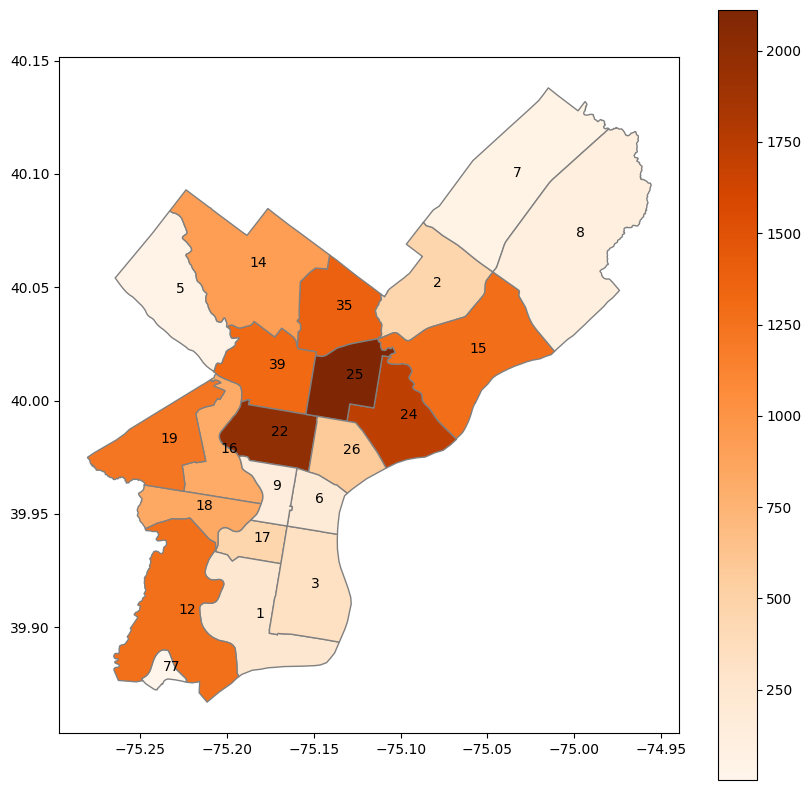

In [79]:
ppd_dist_counts_gdf.plot(edgecolor='gray', column='count', figsize=(10,10), 
                         legend=True, cmap='Oranges')

ppd_dist_counts_gdf.apply(lambda r: plt.text(r['centX'], r['centY'], r['DIST_NUM']),axis=1)

plt.show()